# Final Five-Component Gaussian Mixture Model Selection  
## GMM C5 Spherical vs GMM C5 Diagonal

### Purpose

The previous GMM evaluation compared component counts from 2 to 10 and four
covariance structures.

Two five-component configurations satisfied the practical component-size
condition and remained relevant for direct comparison with K-Means K=5:

- `GMM_C5_spherical`
- `GMM_C5_diag`

This notebook:

1. loads the same 4,338 customers and seven processed features;
2. trains both five-component configurations under identical conditions;
3. evaluates their likelihood fit, common internal validation and component
   feasibility;
4. tests both models across 30 random states;
5. tests both models across 50 repeated 80% customer subsamples;
6. compares membership-probability decisiveness;
7. compares original-scale component profiles;
8. records agreement between the two GMM solutions;
9. selects and freezes a final five-component GMM only when the transparent
   operational selection conditions are satisfied.

### Scope boundary

This notebook uses probability summaries only to support model selection.
Detailed customer-level probability categories, alternative components and
entropy-based uncertainty analysis belong to the next notebook.

## Selection principle

The final operational five-component GMM is not selected by AIC or BIC alone.

The decision follows this order:

1. **Technical validity**
   - successful convergence;
   - five populated components;
   - smallest component at least 5% of customers;
   - valid probability outputs.

2. **Stability**
   - acceptable random-seed stability;
   - acceptable repeated 80% subsampling stability.

3. **Common hard-assignment validation**
   - higher Silhouette Score;
   - lower Davies–Bouldin Index;
   - higher Calinski–Harabasz Index.

4. **Supporting evidence**
   - AIC and BIC;
   - membership-probability decisiveness;
   - original-scale profile interpretability.

AIC and BIC remain important GMM fit measures, but the final operational model
must also create stable, practical and interpretable hard customer groups.

## 1. Import libraries

In [ ]:
import os
import json
import time
import shutil
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure data files and final-model settings

Upload:

- `customer_features_processed.csv`
- `customer_features_ready_for_preprocessing.csv`

The processed dataset is used for fitting. The original-scale dataset is used
for component interpretation.

In [ ]:
PROCESSED_FILE = (
    "/content/customer_features_processed.csv"
)

ORIGINAL_SCALE_FILE = (
    "/content/"
    "customer_features_ready_for_preprocessing.csv"
)

RESULTS_DIR = Path(
    "/content/"
    "Final_GMM_C5_Spherical_vs_Diagonal_Results"
)

TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
MODELS_DIR = RESULTS_DIR / "Models"
ASSIGNMENTS_DIR = RESULTS_DIR / "Assignments"
PROFILES_DIR = RESULTS_DIR / "Profiles"
STABILITY_DIR = RESULTS_DIR / "Stability"
SELECTION_DIR = RESULTS_DIR / "Selection"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    ASSIGNMENTS_DIR,
    PROFILES_DIR,
    STABILITY_DIR,
    SELECTION_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

N_COMPONENTS = 5

CANDIDATE_CONFIGURATIONS = {
    "GMM_C5_spherical": "spherical",
    "GMM_C5_diag": "diag"
}

BASELINE_RANDOM_STATE = 42
BASELINE_N_INIT = 20
MAX_ITER = 500
TOLERANCE = 1e-3
REGULARISATION = 1e-5
INITIALISATION = "kmeans"

SEED_STABILITY_RUNS = 30
SUBSAMPLING_STABILITY_RUNS = 50
SUBSAMPLE_FRACTION = 0.80
STABILITY_N_INIT = 10
SUBSAMPLING_RANDOM_STATE = 2026

MINIMUM_COMPONENT_PERCENTAGE = 5.0

# Descriptive probability evidence for model selection.
LOW_MAXIMUM_PROBABILITY_THRESHOLD = 0.60
LOW_PROBABILITY_MARGIN_THRESHOLD = 0.20

# Project-specific stability screening conditions.
# These are transparent decision rules, not universal standards.
MINIMUM_MEAN_SEED_ARI = 0.80
MINIMUM_WORST_SEED_ARI = 0.60
MINIMUM_MEAN_SUBSAMPLE_ARI = 0.75
MINIMUM_WORST_SUBSAMPLE_ARI = 0.60

print("Candidate configurations:")
print(CANDIDATE_CONFIGURATIONS)
print("Results directory:", RESULTS_DIR)

Candidate configurations:
{'GMM_C5_spherical': 'spherical', 'GMM_C5_diag': 'diag'}
Results directory: /content/Final_GMM_C5_Spherical_vs_Diagonal_Results


### Why use the same settings for both candidates?

Both candidates must be trained with identical:

- customer records;
- feature matrix;
- number of components;
- initialisation method;
- number of initialisations;
- convergence tolerance;
- maximum iterations;
- covariance regularisation;
- seed and subsampling procedures.

Only the covariance structure is allowed to differ. This isolates the effect
of spherical versus diagonal covariance.

## 3. Load and align the customer datasets

In [ ]:
if not os.path.exists(PROCESSED_FILE):
    raise FileNotFoundError(
        f"Processed data not found: {PROCESSED_FILE}"
    )

if not os.path.exists(ORIGINAL_SCALE_FILE):
    raise FileNotFoundError(
        "Original-scale data not found: "
        f"{ORIGINAL_SCALE_FILE}"
    )

processed_data = pd.read_csv(
    PROCESSED_FILE
)

original_scale_data = pd.read_csv(
    ORIGINAL_SCALE_FILE
)

REQUIRED_COLUMNS = [
    "CustomerID"
] + FEATURE_COLUMNS

missing_processed = [
    column
    for column in REQUIRED_COLUMNS
    if column not in processed_data.columns
]

missing_original = [
    column
    for column in REQUIRED_COLUMNS
    if column not in original_scale_data.columns
]

if missing_processed:
    raise ValueError(
        "Missing processed columns: "
        f"{missing_processed}"
    )

if missing_original:
    raise ValueError(
        "Missing original-scale columns: "
        f"{missing_original}"
    )

if processed_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values in processed data."
    )

if original_scale_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values in original-scale data."
    )

original_scale_data = (
    processed_data[["CustomerID"]]
    .merge(
        original_scale_data[
            REQUIRED_COLUMNS
        ],
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

if original_scale_data.isnull().sum().sum() > 0:
    raise ValueError(
        "Original-scale customer alignment failed."
    )

X = processed_data[
    FEATURE_COLUMNS
].copy()

if X.isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in the processed matrix."
    )

if not np.isfinite(
    X.to_numpy()
).all():
    raise ValueError(
        "Non-finite values found in the processed matrix."
    )

EXPECTED_CUSTOMERS = 4338

if len(X) != EXPECTED_CUSTOMERS:
    raise ValueError(
        "Expected the frozen customer population of "
        f"{EXPECTED_CUSTOMERS:,}, but found {len(X):,}."
    )

if X.shape[1] != 7:
    raise ValueError(
        "Expected exactly seven clustering features."
    )

print("=" * 80)
print("INPUT VALIDATION COMPLETED")
print("=" * 80)
print("Customers:", len(X))
print("Features:", X.shape[1])
print("Feature order:", FEATURE_COLUMNS)

display(X.describe().T)

INPUT VALIDATION COMPLETED
Customers: 4338
Features: 7
Feature order: ['Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.0000",0.3350,0.8066,-0.4032,-0.2661,0.0000,0.7339,2.6048
Frequency,"4,338.0000",0.2248,0.6218,-0.3691,-0.3691,0.0000,0.6309,3.8671
Monetary,"4,338.0000",0.0486,0.7459,-2.9331,-0.4613,-0.0000,0.5387,3.5781
AverageOrderValue,"4,338.0000",-0.0388,0.8516,-4.7825,-0.5635,0.0000,0.4365,6.4666
BasketSize,"4,338.0000",-0.0439,0.8450,-4.1088,-0.5189,0.0000,0.4811,5.7289
ProductDiversity,"4,338.0000",-0.0210,0.7427,-1.8972,-0.4925,0.0000,0.5075,2.5634
TotalQuantity,"4,338.0000",0.0239,0.7517,-2.8763,-0.4730,0.0000,0.5270,3.4295


## 4. Record the fixed analytical population

This notebook does not remove additional customers, change the preprocessing
or alter the feature set. This preserves comparability with the frozen
K-Means K=5 model.

In [ ]:
input_validation_summary = pd.DataFrame({
    "Check": [
        "Customer count",
        "Feature count",
        "CustomerID uniqueness",
        "Missing processed values",
        "Finite processed values",
        "Original-scale alignment"
    ],
    "Result": [
        len(X),
        X.shape[1],
        bool(
            processed_data[
                "CustomerID"
            ].is_unique
        ),
        int(
            X.isnull().sum().sum()
        ),
        bool(
            np.isfinite(
                X.to_numpy()
            ).all()
        ),
        bool(
            np.array_equal(
                processed_data[
                    "CustomerID"
                ].to_numpy(),
                original_scale_data[
                    "CustomerID"
                ].to_numpy()
            )
        )
    ]
})

display(input_validation_summary)

input_validation_summary.to_csv(
    TABLES_DIR / "input_validation_summary.csv",
    index=False
)

,Check,Result
0,Customer count,4338
1,Feature count,7
2,CustomerID uniqueness,True
3,Missing processed values,0
4,Finite processed values,True
5,Original-scale alignment,True


## 5. Define model, probability and profile helper functions

In [ ]:
def build_gmm(
    covariance_type,
    random_state,
    n_init
):
    return GaussianMixture(
        n_components=N_COMPONENTS,
        covariance_type=covariance_type,
        tol=TOLERANCE,
        reg_covar=REGULARISATION,
        max_iter=MAX_ITER,
        n_init=n_init,
        init_params=INITIALISATION,
        random_state=random_state
    )


def component_size_table(labels):
    table = (
        pd.Series(
            labels,
            name="Component"
        )
        .value_counts()
        .sort_index()
        .reindex(
            range(N_COMPONENTS),
            fill_value=0
        )
        .rename_axis("Component")
        .reset_index(
            name="Customer_Count"
        )
    )

    table["Customer_Percentage"] = (
        table["Customer_Count"]
        / table["Customer_Count"].sum()
        * 100
    )

    return table


def normalised_entropy(probabilities):
    clipped = np.clip(
        probabilities,
        1e-15,
        1.0
    )

    entropy = -np.sum(
        clipped * np.log(clipped),
        axis=1
    )

    return entropy / np.log(
        probabilities.shape[1]
    )


def probability_summary(probabilities):
    sorted_probabilities = np.sort(
        probabilities,
        axis=1
    )

    maximum_probability = (
        sorted_probabilities[:, -1]
    )

    second_probability = (
        sorted_probabilities[:, -2]
    )

    probability_margin = (
        maximum_probability
        - second_probability
    )

    entropy = normalised_entropy(
        probabilities
    )

    summary = {
        "Mean_Maximum_Probability": float(
            maximum_probability.mean()
        ),
        "Median_Maximum_Probability": float(
            np.median(
                maximum_probability
            )
        ),
        "Low_Maximum_Probability_Count": int(
            (
                maximum_probability
                < LOW_MAXIMUM_PROBABILITY_THRESHOLD
            ).sum()
        ),
        "Low_Maximum_Probability_Percentage": float(
            (
                maximum_probability
                < LOW_MAXIMUM_PROBABILITY_THRESHOLD
            ).mean()
            * 100
        ),
        "Mean_Probability_Margin": float(
            probability_margin.mean()
        ),
        "Median_Probability_Margin": float(
            np.median(
                probability_margin
            )
        ),
        "Low_Probability_Margin_Count": int(
            (
                probability_margin
                < LOW_PROBABILITY_MARGIN_THRESHOLD
            ).sum()
        ),
        "Low_Probability_Margin_Percentage": float(
            (
                probability_margin
                < LOW_PROBABILITY_MARGIN_THRESHOLD
            ).mean()
            * 100
        ),
        "Mean_Normalised_Entropy": float(
            entropy.mean()
        ),
        "Median_Normalised_Entropy": float(
            np.median(
                entropy
            )
        )
    }

    customer_values = {
        "Maximum_Probability": maximum_probability,
        "Second_Probability": second_probability,
        "Probability_Margin": probability_margin,
        "Normalised_Entropy": entropy
    }

    return summary, customer_values


def minimum_covariance_value(model):
    covariance = model.covariances_

    if model.covariance_type == "full":
        return float(
            min(
                np.linalg.eigvalsh(
                    matrix
                ).min()
                for matrix in covariance
            )
        )

    if model.covariance_type == "tied":
        return float(
            np.linalg.eigvalsh(
                covariance
            ).min()
        )

    return float(
        np.min(covariance)
    )


def create_original_scale_profiles(
    labels,
    configuration
):
    profile_data = (
        original_scale_data.copy()
    )

    profile_data[
        "Component"
    ] = labels

    mean_profile = (
        profile_data
        .groupby(
            "Component"
        )[FEATURE_COLUMNS]
        .mean()
        .round(4)
    )

    median_profile = (
        profile_data
        .groupby(
            "Component"
        )[FEATURE_COLUMNS]
        .median()
        .round(4)
    )

    quartile_profile = (
        profile_data
        .groupby(
            "Component"
        )[FEATURE_COLUMNS]
        .quantile(
            [0.25, 0.75]
        )
        .unstack()
    )

    mean_profile.to_csv(
        PROFILES_DIR
        / f"{configuration}_mean_profile.csv"
    )

    median_profile.to_csv(
        PROFILES_DIR
        / f"{configuration}_median_profile.csv"
    )

    quartile_profile.to_csv(
        PROFILES_DIR
        / f"{configuration}_quartile_profile.csv"
    )

    return (
        mean_profile,
        median_profile,
        quartile_profile
    )

## 6. Train the two baseline five-component candidates

Both models are trained using:

- random state 42;
- 20 initialisations;
- K-Means-based initial means;
- 500 maximum EM iterations;
- the same covariance regularisation.

In [ ]:
baseline_models = {}
baseline_labels = {}
baseline_probabilities = {}
baseline_probability_values = {}
baseline_profiles = {}
baseline_component_sizes = {}
baseline_results = []

for configuration, covariance_type in (
    CANDIDATE_CONFIGURATIONS.items()
):

    print("\n" + "=" * 90)
    print("TRAINING", configuration)
    print("=" * 90)

    start_time = time.perf_counter()

    model = build_gmm(
        covariance_type=covariance_type,
        random_state=BASELINE_RANDOM_STATE,
        n_init=BASELINE_N_INIT
    )

    labels = model.fit_predict(X)

    fit_time = (
        time.perf_counter()
        - start_time
    )

    unique_components = np.unique(
        labels
    )

    if len(unique_components) != N_COMPONENTS:
        raise ValueError(
            f"{configuration} produced "
            f"{len(unique_components)} populated components."
        )

    probabilities = model.predict_proba(X)

    if not np.allclose(
        probabilities.sum(axis=1),
        1.0
    ):
        raise ValueError(
            f"{configuration} probabilities do not sum to one."
        )

    probability_metrics, customer_probability_values = (
        probability_summary(
            probabilities
        )
    )

    silhouette = silhouette_score(
        X,
        labels
    )

    dbi = davies_bouldin_score(
        X,
        labels
    )

    ch = calinski_harabasz_score(
        X,
        labels
    )

    individual_silhouette = (
        silhouette_samples(
            X,
            labels
        )
    )

    size_table = component_size_table(
        labels
    )

    (
        mean_profile,
        median_profile,
        quartile_profile
    ) = create_original_scale_profiles(
        labels=labels,
        configuration=configuration
    )

    assignment_data = pd.DataFrame({
        "CustomerID": (
            processed_data[
                "CustomerID"
            ]
        ),
        "Component": labels,
        "Silhouette_Value": (
            individual_silhouette
        ),
        **customer_probability_values
    })

    for component_index in range(
        N_COMPONENTS
    ):
        assignment_data[
            f"Component_{component_index}_Probability"
        ] = probabilities[
            :,
            component_index
        ]

    assignment_data.to_csv(
        ASSIGNMENTS_DIR
        / f"{configuration}_customer_assignments.csv",
        index=False
    )

    size_table.to_csv(
        TABLES_DIR
        / f"{configuration}_component_sizes.csv",
        index=False
    )

    joblib.dump(
        model,
        MODELS_DIR
        / f"{configuration}_baseline_model.joblib"
    )

    result = {
        "Configuration": configuration,
        "N_Components": N_COMPONENTS,
        "Covariance_Type": covariance_type,
        "Converged": bool(
            model.converged_
        ),
        "Iterations": int(
            model.n_iter_
        ),
        "Fit_Time_Seconds": float(
            fit_time
        ),
        "Average_Log_Likelihood": float(
            model.score(X)
        ),
        "Lower_Bound": float(
            model.lower_bound_
        ),
        "AIC": float(
            model.aic(X)
        ),
        "BIC": float(
            model.bic(X)
        ),
        "Silhouette_Score": float(
            silhouette
        ),
        "Negative_Silhouette_Count": int(
            (
                individual_silhouette < 0
            ).sum()
        ),
        "Negative_Silhouette_Percentage": float(
            (
                individual_silhouette < 0
            ).mean()
            * 100
        ),
        "Davies_Bouldin_Index": float(
            dbi
        ),
        "Calinski_Harabasz_Index": float(
            ch
        ),
        "Smallest_Component_Count": int(
            size_table[
                "Customer_Count"
            ].min()
        ),
        "Smallest_Component_Percentage": float(
            size_table[
                "Customer_Percentage"
            ].min()
        ),
        "Largest_Component_Percentage": float(
            size_table[
                "Customer_Percentage"
            ].max()
        ),
        "All_Components_At_Least_5_Percent": bool(
            size_table[
                "Customer_Percentage"
            ].min()
            >= MINIMUM_COMPONENT_PERCENTAGE
        ),
        "Minimum_Covariance_Value": (
            minimum_covariance_value(
                model
            )
        ),
        **probability_metrics
    }

    baseline_results.append(
        result
    )

    baseline_models[
        configuration
    ] = model

    baseline_labels[
        configuration
    ] = labels

    baseline_probabilities[
        configuration
    ] = probabilities

    baseline_probability_values[
        configuration
    ] = customer_probability_values

    baseline_component_sizes[
        configuration
    ] = size_table

    baseline_profiles[
        configuration
    ] = {
        "mean": mean_profile,
        "median": median_profile,
        "quartile": quartile_profile
    }

baseline_results_df = (
    pd.DataFrame(
        baseline_results
    )
    .round(6)
)

display(baseline_results_df)

baseline_results_df.to_csv(
    TABLES_DIR
    / "gmm_c5_baseline_comparison.csv",
    index=False
)


TRAINING GMM_C5_spherical

TRAINING GMM_C5_diag


,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Negative_Silhouette_Count,Negative_Silhouette_Percentage,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,All_Components_At_Least_5_Percent,Minimum_Covariance_Value,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Median_Normalised_Entropy
0,GMM_C5_spherical,5,spherical,True,11,1.0625,-5.8326,-5.8329,"50,691.2165","50,971.7240",0.2299,628,14.4767,1.3749,"1,587.4952",494,11.3877,37.0678,True,0.1421,0.9221,0.9908,227,5.2328,0.8503,0.9827,194,4.4721,0.1201,0.0338
1,GMM_C5_diag,5,diag,True,20,1.4986,-4.2417,-4.2422,"36,948.9499","37,420.7124",0.1329,1174,27.0632,1.7975,"1,149.3977",351,8.0913,31.1664,True,0.0000,0.9516,0.9982,126,2.9046,0.9042,0.9965,123,2.8354,0.0743,0.0085


## 7. Test random-seed stability

Each covariance structure is fitted 30 times using different random states.

For every run, the hard component assignments are compared with the
corresponding random-state-42 baseline using Adjusted Rand Index.

ARI is unaffected by component-number permutations.

In [ ]:
seed_run_records = []
seed_summary_records = []

for configuration, covariance_type in (
    CANDIDATE_CONFIGURATIONS.items()
):

    reference_labels = (
        baseline_labels[
            configuration
        ]
    )

    configuration_records = []

    print("\n" + "=" * 80)
    print(
        "RANDOM-SEED STABILITY:",
        configuration
    )
    print("=" * 80)

    for random_state in range(
        1,
        SEED_STABILITY_RUNS + 1
    ):

        start_time = time.perf_counter()

        try:
            model = build_gmm(
                covariance_type=covariance_type,
                random_state=random_state,
                n_init=STABILITY_N_INIT
            )

            labels = model.fit_predict(X)

            run_ari = adjusted_rand_score(
                reference_labels,
                labels
            )

            record = {
                "Configuration": configuration,
                "Covariance_Type": covariance_type,
                "Random_State": random_state,
                "Converged": bool(
                    model.converged_
                ),
                "Iterations": int(
                    model.n_iter_
                ),
                "Adjusted_Rand_Index": float(
                    run_ari
                ),
                "AIC": float(
                    model.aic(X)
                ),
                "BIC": float(
                    model.bic(X)
                ),
                "Fit_Time_Seconds": float(
                    time.perf_counter()
                    - start_time
                ),
                "Error": None
            }

        except Exception as error:

            record = {
                "Configuration": configuration,
                "Covariance_Type": covariance_type,
                "Random_State": random_state,
                "Converged": False,
                "Iterations": np.nan,
                "Adjusted_Rand_Index": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "Fit_Time_Seconds": float(
                    time.perf_counter()
                    - start_time
                ),
                "Error": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                )
            }

        seed_run_records.append(
            record
        )

        configuration_records.append(
            record
        )

    configuration_df = pd.DataFrame(
        configuration_records
    )

    successful = configuration_df[
        configuration_df[
            "Adjusted_Rand_Index"
        ].notna()
    ]

    seed_summary_records.append({
        "Configuration": configuration,
        "Covariance_Type": covariance_type,
        "Requested_Runs": SEED_STABILITY_RUNS,
        "Successful_Runs": int(
            len(successful)
        ),
        "Convergence_Rate": float(
            configuration_df[
                "Converged"
            ].mean()
        ),
        "Mean_Seed_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].mean()
        ),
        "Median_Seed_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].median()
        ),
        "Minimum_Seed_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].min()
        ),
        "Maximum_Seed_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].max()
        ),
        "Seed_ARI_Standard_Deviation": float(
            successful[
                "Adjusted_Rand_Index"
            ].std()
        ),
        "Mean_AIC_Across_Seeds": float(
            successful[
                "AIC"
            ].mean()
        ),
        "Mean_BIC_Across_Seeds": float(
            successful[
                "BIC"
            ].mean()
        )
    })

seed_runs_df = pd.DataFrame(
    seed_run_records
)

seed_summary_df = (
    pd.DataFrame(
        seed_summary_records
    )
    .round(6)
)

display(seed_summary_df)

seed_runs_df.to_csv(
    STABILITY_DIR
    / "gmm_c5_random_seed_runs.csv",
    index=False
)

seed_summary_df.to_csv(
    STABILITY_DIR
    / "gmm_c5_random_seed_summary.csv",
    index=False
)


RANDOM-SEED STABILITY: GMM_C5_spherical

RANDOM-SEED STABILITY: GMM_C5_diag


,Configuration,Covariance_Type,Requested_Runs,Successful_Runs,Convergence_Rate,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_AIC_Across_Seeds,Mean_BIC_Across_Seeds
0,GMM_C5_spherical,spherical,30,30,1.0000,0.9985,0.9992,0.9918,1.0000,0.0020,"50,691.2220","50,971.7294"
1,GMM_C5_diag,diag,30,30,1.0000,0.7894,0.7902,0.6129,1.0000,0.1538,"37,173.8006","37,645.5631"


## 8. Test repeated 80% customer-subsampling stability

For each configuration:

1. draw 80% of customers without replacement;
2. fit the same five-component GMM;
3. compare the sample assignments with the full-data baseline restricted to
   the sampled customers;
4. calculate ARI.

Both configurations use the same customer samples in every run.

In [ ]:
sample_size = int(
    len(X)
    * SUBSAMPLE_FRACTION
)

sample_generator = np.random.default_rng(
    SUBSAMPLING_RANDOM_STATE
)

shared_subsamples = [
    np.sort(
        sample_generator.choice(
            len(X),
            size=sample_size,
            replace=False
        )
    )
    for _ in range(
        SUBSAMPLING_STABILITY_RUNS
    )
]

subsample_run_records = []
subsample_summary_records = []

for configuration, covariance_type in (
    CANDIDATE_CONFIGURATIONS.items()
):

    reference_labels = (
        baseline_labels[
            configuration
        ]
    )

    configuration_records = []

    print("\n" + "=" * 80)
    print(
        "80% SUBSAMPLING STABILITY:",
        configuration
    )
    print("=" * 80)

    for run_number, sampled_positions in enumerate(
        shared_subsamples,
        start=1
    ):

        X_sample = X.iloc[
            sampled_positions
        ]

        reference_sample_labels = (
            reference_labels[
                sampled_positions
            ]
        )

        start_time = time.perf_counter()

        try:
            model = build_gmm(
                covariance_type=covariance_type,
                random_state=(
                    SUBSAMPLING_RANDOM_STATE
                    + run_number
                ),
                n_init=STABILITY_N_INIT
            )

            sample_labels = model.fit_predict(
                X_sample
            )

            run_ari = adjusted_rand_score(
                reference_sample_labels,
                sample_labels
            )

            sample_component_sizes = (
                component_size_table(
                    sample_labels
                )
            )

            record = {
                "Configuration": configuration,
                "Covariance_Type": covariance_type,
                "Run": run_number,
                "Sample_Size": sample_size,
                "Sample_Fraction": (
                    SUBSAMPLE_FRACTION
                ),
                "Converged": bool(
                    model.converged_
                ),
                "Iterations": int(
                    model.n_iter_
                ),
                "Adjusted_Rand_Index": float(
                    run_ari
                ),
                "Smallest_Sample_Component_Percentage": float(
                    sample_component_sizes[
                        "Customer_Percentage"
                    ].min()
                ),
                "Fit_Time_Seconds": float(
                    time.perf_counter()
                    - start_time
                ),
                "Error": None
            }

        except Exception as error:

            record = {
                "Configuration": configuration,
                "Covariance_Type": covariance_type,
                "Run": run_number,
                "Sample_Size": sample_size,
                "Sample_Fraction": (
                    SUBSAMPLE_FRACTION
                ),
                "Converged": False,
                "Iterations": np.nan,
                "Adjusted_Rand_Index": np.nan,
                "Smallest_Sample_Component_Percentage": (
                    np.nan
                ),
                "Fit_Time_Seconds": float(
                    time.perf_counter()
                    - start_time
                ),
                "Error": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                )
            }

        subsample_run_records.append(
            record
        )

        configuration_records.append(
            record
        )

    configuration_df = pd.DataFrame(
        configuration_records
    )

    successful = configuration_df[
        configuration_df[
            "Adjusted_Rand_Index"
        ].notna()
    ]

    subsample_summary_records.append({
        "Configuration": configuration,
        "Covariance_Type": covariance_type,
        "Requested_Runs": (
            SUBSAMPLING_STABILITY_RUNS
        ),
        "Successful_Runs": int(
            len(successful)
        ),
        "Sample_Size": sample_size,
        "Sample_Fraction": (
            SUBSAMPLE_FRACTION
        ),
        "Convergence_Rate": float(
            configuration_df[
                "Converged"
            ].mean()
        ),
        "Mean_Subsampling_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].mean()
        ),
        "Median_Subsampling_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].median()
        ),
        "Minimum_Subsampling_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].min()
        ),
        "Maximum_Subsampling_ARI": float(
            successful[
                "Adjusted_Rand_Index"
            ].max()
        ),
        "Subsampling_ARI_Standard_Deviation": float(
            successful[
                "Adjusted_Rand_Index"
            ].std()
        ),
        "Mean_Smallest_Sample_Component_Percentage": float(
            successful[
                "Smallest_Sample_Component_Percentage"
            ].mean()
        ),
        "Minimum_Smallest_Sample_Component_Percentage": float(
            successful[
                "Smallest_Sample_Component_Percentage"
            ].min()
        )
    })

subsample_runs_df = pd.DataFrame(
    subsample_run_records
)

subsample_summary_df = (
    pd.DataFrame(
        subsample_summary_records
    )
    .round(6)
)

display(subsample_summary_df)

subsample_runs_df.to_csv(
    STABILITY_DIR
    / "gmm_c5_subsampling_runs.csv",
    index=False
)

subsample_summary_df.to_csv(
    STABILITY_DIR
    / "gmm_c5_subsampling_summary.csv",
    index=False
)


80% SUBSAMPLING STABILITY: GMM_C5_spherical

80% SUBSAMPLING STABILITY: GMM_C5_diag


,Configuration,Covariance_Type,Requested_Runs,Successful_Runs,Sample_Size,Sample_Fraction,Convergence_Rate,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation,Mean_Smallest_Sample_Component_Percentage,Minimum_Smallest_Sample_Component_Percentage
0,GMM_C5_spherical,spherical,50,50,3470,0.8000,1.0000,0.9610,0.9660,0.8898,0.9879,0.0202,11.4259,10.7781
1,GMM_C5_diag,diag,50,50,3470,0.8000,1.0000,0.7621,0.7355,0.5005,0.9854,0.1398,7.4680,5.4755


## 9. Build the consolidated five-component evidence table

In [ ]:
comparison_evidence = (
    baseline_results_df
    .merge(
        seed_summary_df,
        on=[
            "Configuration",
            "Covariance_Type"
        ],
        how="left",
        validate="one_to_one"
    )
    .merge(
        subsample_summary_df,
        on=[
            "Configuration",
            "Covariance_Type"
        ],
        how="left",
        validate="one_to_one",
        suffixes=(
            "_Seed",
            "_Subsample"
        )
    )
    .round(6)
)

comparison_evidence[
    "Passes_Component_Feasibility"
] = (
    comparison_evidence[
        "Smallest_Component_Percentage"
    ]
    >= MINIMUM_COMPONENT_PERCENTAGE
)

comparison_evidence[
    "Passes_Seed_Stability"
] = (
    (
        comparison_evidence[
            "Mean_Seed_ARI"
        ]
        >= MINIMUM_MEAN_SEED_ARI
    )
    &
    (
        comparison_evidence[
            "Minimum_Seed_ARI"
        ]
        >= MINIMUM_WORST_SEED_ARI
    )
)

comparison_evidence[
    "Passes_Subsampling_Stability"
] = (
    (
        comparison_evidence[
            "Mean_Subsampling_ARI"
        ]
        >= MINIMUM_MEAN_SUBSAMPLE_ARI
    )
    &
    (
        comparison_evidence[
            "Minimum_Subsampling_ARI"
        ]
        >= MINIMUM_WORST_SUBSAMPLE_ARI
    )
)

comparison_evidence[
    "Passes_Operational_Gates"
] = (
    comparison_evidence[
        "Converged"
    ]
    &
    comparison_evidence[
        "Passes_Component_Feasibility"
    ]
    &
    comparison_evidence[
        "Passes_Seed_Stability"
    ]
    &
    comparison_evidence[
        "Passes_Subsampling_Stability"
    ]
)

display(comparison_evidence)

comparison_evidence.to_csv(
    TABLES_DIR
    / "gmm_c5_complete_comparison_evidence.csv",
    index=False
)

,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Negative_Silhouette_Count,Negative_Silhouette_Percentage,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,All_Components_At_Least_5_Percent,Minimum_Covariance_Value,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Median_Normalised_Entropy,Requested_Runs_Seed,Successful_Runs_Seed,Convergence_Rate_Seed,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_AIC_Across_Seeds,Mean_BIC_Across_Seeds,Requested_Runs_Subsample,Successful_Runs_Subsample,Sample_Size,Sample_Fraction,Convergence_Rate_Subsample,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation,Mean_Smallest_Sample_Component_Percentage,Minimum_Smallest_Sample_Component_Percentage,Passes_Component_Feasibility,Passes_Seed_Stability,Passes_Subsampling_Stability,Passes_Operational_Gates
0,GMM_C5_spherical,5,spherical,True,11,1.0625,-5.8326,-5.8329,"50,691.2165","50,971.7240",0.2299,628,14.4767,1.3749,"1,587.4952",494,11.3877,37.0678,True,0.1421,0.9221,0.9908,227,5.2328,0.8503,0.9827,194,4.4721,0.1201,0.0338,30,30,1.0000,0.9985,0.9992,0.9918,1.0000,0.0020,"50,691.2220","50,971.7294",50,50,3470,0.8000,1.0000,0.9610,0.9660,0.8898,0.9879,0.0202,11.4259,10.7781,True,True,True,True
1,GMM_C5_diag,5,diag,True,20,1.4986,-4.2417,-4.2422,"36,948.9499","37,420.7124",0.1329,1174,27.0632,1.7975,"1,149.3977",351,8.0913,31.1664,True,0.0000,0.9516,0.9982,126,2.9046,0.9042,0.9965,123,2.8354,0.0743,0.0085,30,30,1.0000,0.7894,0.7902,0.6129,1.0000,0.1538,"37,173.8006","37,645.5631",50,50,3470,0.8000,1.0000,0.7621,0.7355,0.5005,0.9854,0.1398,7.4680,5.4755,True,False,False,False


## 10. Show the criterion-level winner without creating an equal-weight score

The table records which candidate is stronger for each criterion.

It does not sum all metrics into one arbitrary score. Operational gates and
the three common validation measures are interpreted before likelihood and
probability evidence.

In [ ]:
spherical_row = (
    comparison_evidence[
        comparison_evidence[
            "Configuration"
        ] == "GMM_C5_spherical"
    ]
    .iloc[0]
)

diagonal_row = (
    comparison_evidence[
        comparison_evidence[
            "Configuration"
        ] == "GMM_C5_diag"
    ]
    .iloc[0]
)

criterion_definitions = [
    (
        "Silhouette Score",
        "Silhouette_Score",
        "higher",
        "Common hard-assignment validation"
    ),
    (
        "Davies-Bouldin Index",
        "Davies_Bouldin_Index",
        "lower",
        "Common hard-assignment validation"
    ),
    (
        "Calinski-Harabasz Index",
        "Calinski_Harabasz_Index",
        "higher",
        "Common hard-assignment validation"
    ),
    (
        "Mean random-seed ARI",
        "Mean_Seed_ARI",
        "higher",
        "Model stability"
    ),
    (
        "Minimum random-seed ARI",
        "Minimum_Seed_ARI",
        "higher",
        "Model stability"
    ),
    (
        "Mean subsampling ARI",
        "Mean_Subsampling_ARI",
        "higher",
        "Model stability"
    ),
    (
        "Minimum subsampling ARI",
        "Minimum_Subsampling_ARI",
        "higher",
        "Model stability"
    ),
    (
        "Smallest component percentage",
        "Smallest_Component_Percentage",
        "higher",
        "Operational feasibility"
    ),
    (
        "Mean maximum probability",
        "Mean_Maximum_Probability",
        "higher",
        "Probability decisiveness"
    ),
    (
        "Mean probability margin",
        "Mean_Probability_Margin",
        "higher",
        "Probability decisiveness"
    ),
    (
        "Mean normalised entropy",
        "Mean_Normalised_Entropy",
        "lower",
        "Probability decisiveness"
    ),
    (
        "AIC",
        "AIC",
        "lower",
        "Likelihood-based model fit"
    ),
    (
        "BIC",
        "BIC",
        "lower",
        "Likelihood-based model fit"
    )
]

criterion_rows = []

for (
    criterion,
    column,
    preferred_direction,
    evidence_group
) in criterion_definitions:

    spherical_value = float(
        spherical_row[
            column
        ]
    )

    diagonal_value = float(
        diagonal_row[
            column
        ]
    )

    if np.isclose(
        spherical_value,
        diagonal_value
    ):
        winner = "Tie"
    elif preferred_direction == "higher":
        winner = (
            "GMM_C5_spherical"
            if spherical_value > diagonal_value
            else "GMM_C5_diag"
        )
    else:
        winner = (
            "GMM_C5_spherical"
            if spherical_value < diagonal_value
            else "GMM_C5_diag"
        )

    criterion_rows.append({
        "Evidence_Group": evidence_group,
        "Criterion": criterion,
        "Preferred_Direction": (
            preferred_direction
        ),
        "GMM_C5_spherical": spherical_value,
        "GMM_C5_diag": diagonal_value,
        "Criterion_Winner": winner
    })

criterion_comparison = (
    pd.DataFrame(
        criterion_rows
    )
    .round(6)
)

display(criterion_comparison)

criterion_comparison.to_csv(
    TABLES_DIR
    / "gmm_c5_criterion_comparison.csv",
    index=False
)

,Evidence_Group,Criterion,Preferred_Direction,GMM_C5_spherical,GMM_C5_diag,Criterion_Winner
0,Common hard-assignment validation,Silhouette Score,higher,0.2299,0.1329,GMM_C5_spherical
1,Common hard-assignment validation,Davies-Bouldin Index,lower,1.3749,1.7975,GMM_C5_spherical
2,Common hard-assignment validation,Calinski-Harabasz Index,higher,"1,587.4952","1,149.3977",GMM_C5_spherical
3,Model stability,Mean random-seed ARI,higher,0.9985,0.7894,GMM_C5_spherical
4,Model stability,Minimum random-seed ARI,higher,0.9918,0.6129,GMM_C5_spherical
5,Model stability,Mean subsampling ARI,higher,0.9610,0.7621,GMM_C5_spherical
6,Model stability,Minimum subsampling ARI,higher,0.8898,0.5005,GMM_C5_spherical
7,Operational feasibility,Smallest component percentage,higher,11.3877,8.0913,GMM_C5_spherical
8,Probability decisiveness,Mean maximum probability,higher,0.9221,0.9516,GMM_C5_diag
9,Probability decisiveness,Mean probability margin,higher,0.8503,0.9042,GMM_C5_diag


## 11. Measure agreement between spherical and diagonal GMM assignments

Component numbers are arbitrary.

The notebook therefore:

- calculates ARI and NMI directly;
- aligns diagonal components to spherical components using maximum customer
  overlap;
- creates an aligned contingency matrix.

This comparison shows how differently the covariance assumptions divide the
same customers.

In [ ]:
spherical_labels = (
    baseline_labels[
        "GMM_C5_spherical"
    ]
)

diagonal_labels = (
    baseline_labels[
        "GMM_C5_diag"
    ]
)

cross_model_ari = adjusted_rand_score(
    spherical_labels,
    diagonal_labels
)

cross_model_nmi = (
    normalized_mutual_info_score(
        spherical_labels,
        diagonal_labels
    )
)

raw_contingency = pd.crosstab(
    pd.Series(
        spherical_labels,
        name="Spherical_Component"
    ),
    pd.Series(
        diagonal_labels,
        name="Diagonal_Component"
    )
).reindex(
    index=range(N_COMPONENTS),
    columns=range(N_COMPONENTS),
    fill_value=0
)

row_ind, col_ind = linear_sum_assignment(
    -raw_contingency.to_numpy()
)

diagonal_to_spherical_mapping = {
    int(diagonal_component): int(
        spherical_component
    )
    for (
        spherical_component,
        diagonal_component
    ) in zip(
        row_ind,
        col_ind
    )
}

aligned_diagonal_labels = np.array([
    diagonal_to_spherical_mapping[
        int(label)
    ]
    for label in diagonal_labels
])

aligned_contingency = pd.crosstab(
    pd.Series(
        spherical_labels,
        name="Spherical_Component"
    ),
    pd.Series(
        aligned_diagonal_labels,
        name="Aligned_Diagonal_Component"
    ),
    margins=True,
    margins_name="Total"
)

model_agreement_summary = pd.DataFrame({
    "Measure": [
        "Adjusted Rand Index",
        "Normalised Mutual Information",
        "Exact agreement after overlap alignment"
    ],
    "Value": [
        cross_model_ari,
        cross_model_nmi,
        float(
            (
                spherical_labels
                == aligned_diagonal_labels
            ).mean()
        )
    ]
})

component_alignment = pd.DataFrame({
    "Original_Diagonal_Component": list(
        diagonal_to_spherical_mapping.keys()
    ),
    "Aligned_Spherical_Component": list(
        diagonal_to_spherical_mapping.values()
    )
}).sort_values(
    "Original_Diagonal_Component"
)

display(model_agreement_summary)
display(component_alignment)
display(aligned_contingency)

model_agreement_summary.to_csv(
    TABLES_DIR
    / "gmm_c5_model_agreement_summary.csv",
    index=False
)

component_alignment.to_csv(
    TABLES_DIR
    / "gmm_c5_component_alignment.csv",
    index=False
)

aligned_contingency.to_csv(
    TABLES_DIR
    / "gmm_c5_aligned_contingency_matrix.csv"
)

,Measure,Value
0,Adjusted Rand Index,0.4449
1,Normalised Mutual Information,0.5077
2,Exact agreement after overlap alignment,0.6913


,Original_Diagonal_Component,Aligned_Spherical_Component
4,0,4
0,1,0
1,2,1
3,3,3
2,4,2


Aligned_Diagonal_Component,0,1,2,3,4,Total
Spherical_Component,,,,,,
0,1059,0,27,494,28,1608
1,29,291,64,110,0,494
2,48,58,911,0,0,1017
3,87,0,0,412,29,528
4,26,2,1,336,326,691
Total,1249,351,1003,1352,383,4338


## 12. Compare component sizes and original-scale profiles

,Component,Customer_Count,Customer_Percentage,Configuration
0,0,1608,37.0678,GMM_C5_spherical
1,1,494,11.3877,GMM_C5_spherical
2,2,1017,23.4440,GMM_C5_spherical
3,3,528,12.1715,GMM_C5_spherical
4,4,691,15.9290,GMM_C5_spherical
5,0,383,8.8290,GMM_C5_diag
6,1,1249,28.7921,GMM_C5_diag
7,2,351,8.0913,GMM_C5_diag
8,3,1352,31.1664,GMM_C5_diag
9,4,1003,23.1213,GMM_C5_diag


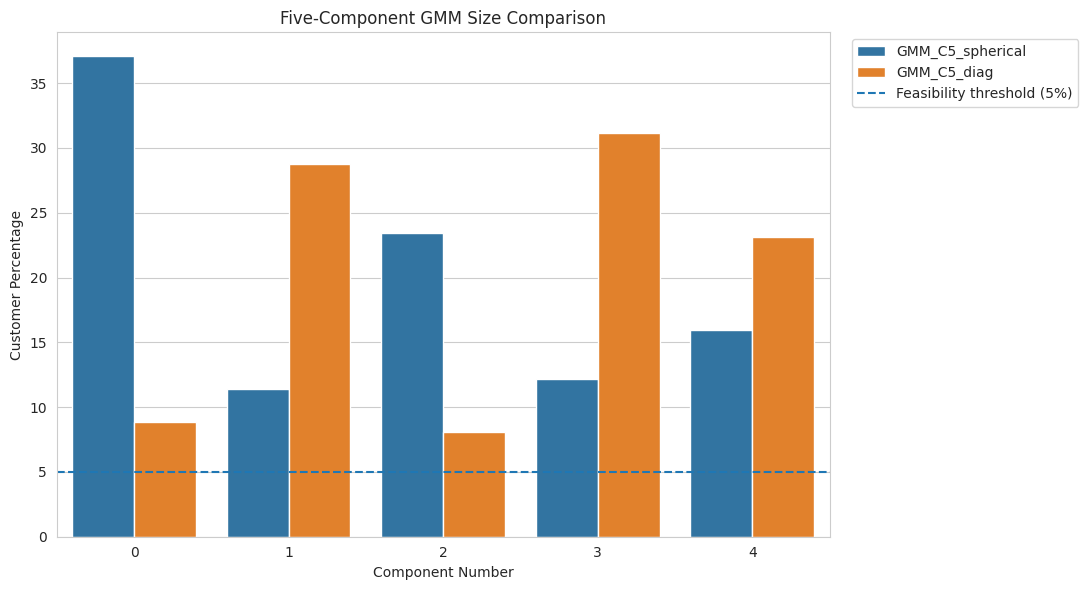

In [ ]:
component_size_comparison = pd.concat(
    [
        baseline_component_sizes[
            configuration
        ].assign(
            Configuration=configuration
        )
        for configuration in (
            CANDIDATE_CONFIGURATIONS
        )
    ],
    ignore_index=True
)

display(component_size_comparison)

component_size_comparison.to_csv(
    TABLES_DIR
    / "gmm_c5_component_size_comparison.csv",
    index=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=component_size_comparison,
    x="Component",
    y="Customer_Percentage",
    hue="Configuration"
)

plt.axhline(
    MINIMUM_COMPONENT_PERCENTAGE,
    linestyle="--",
    label=(
        f"Feasibility threshold "
        f"({MINIMUM_COMPONENT_PERCENTAGE:.0f}%)"
    )
)

plt.title(
    "Five-Component GMM Size Comparison"
)
plt.xlabel("Component Number")
plt.ylabel("Customer Percentage")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_c5_component_size_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

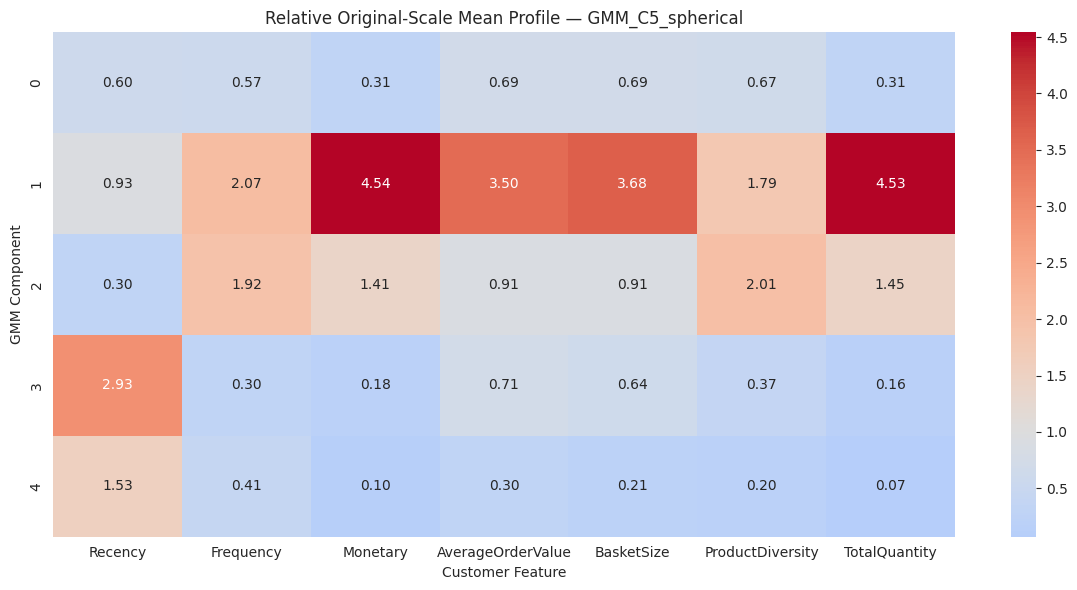

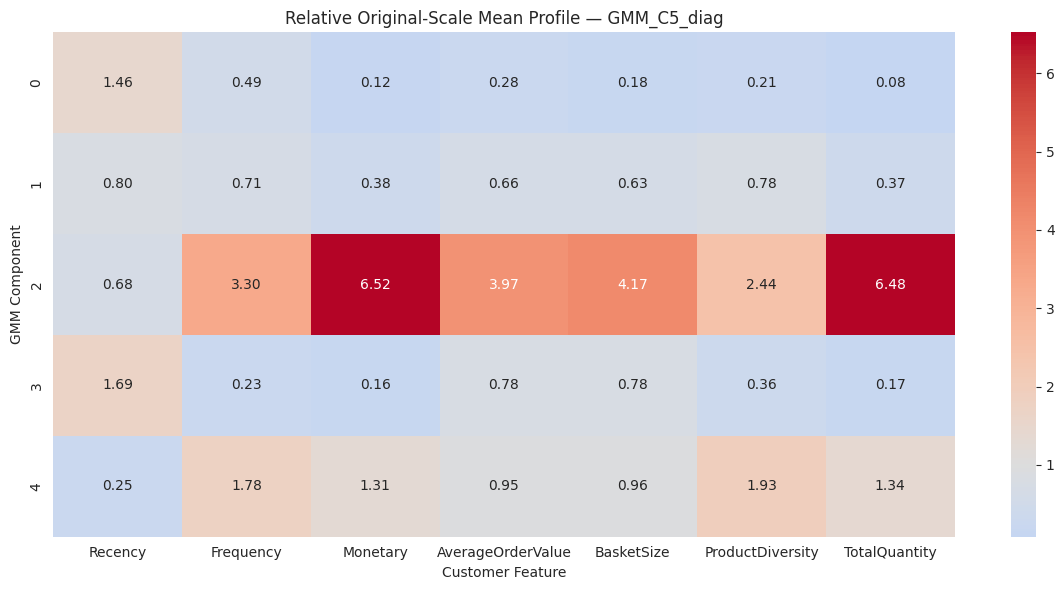

In [ ]:
overall_feature_means = (
    original_scale_data[
        FEATURE_COLUMNS
    ]
    .mean()
)

for configuration in CANDIDATE_CONFIGURATIONS:

    mean_profile = (
        baseline_profiles[
            configuration
        ]["mean"]
    )

    relative_mean_profile = (
        mean_profile
        / overall_feature_means
    )

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        relative_mean_profile,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=1
    )

    plt.title(
        f"Relative Original-Scale Mean Profile — "
        f"{configuration}"
    )
    plt.xlabel("Customer Feature")
    plt.ylabel("GMM Component")
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"{configuration}_relative_mean_profile.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 13. Visualise seed and subsampling stability

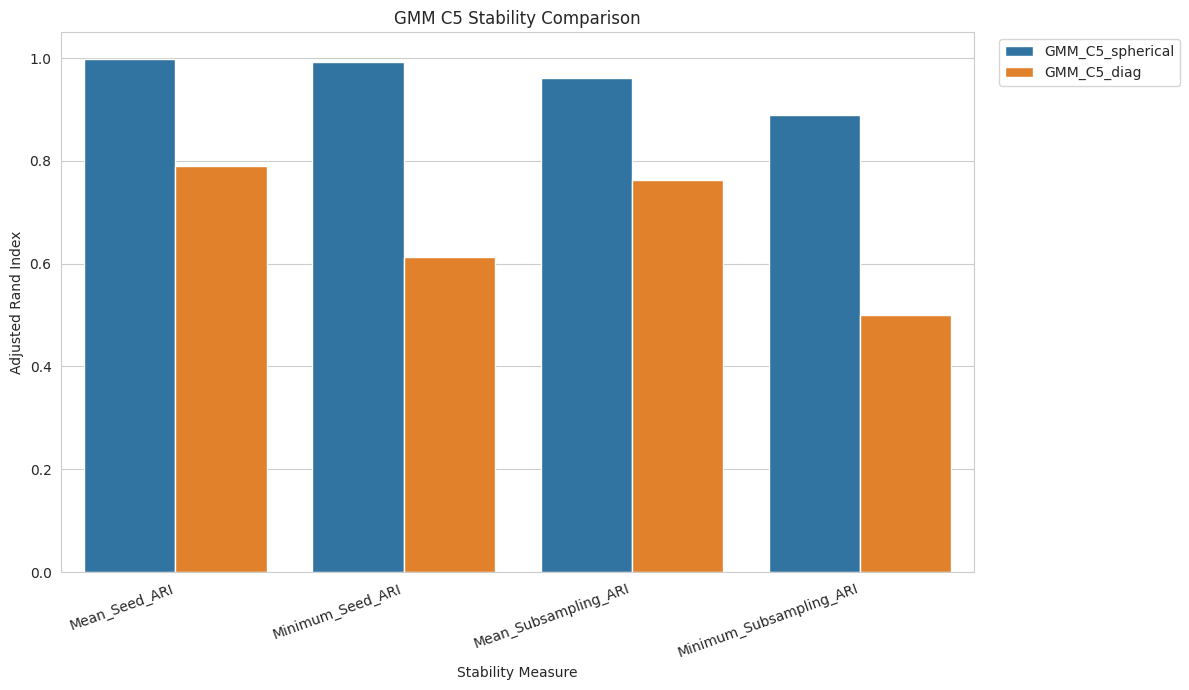

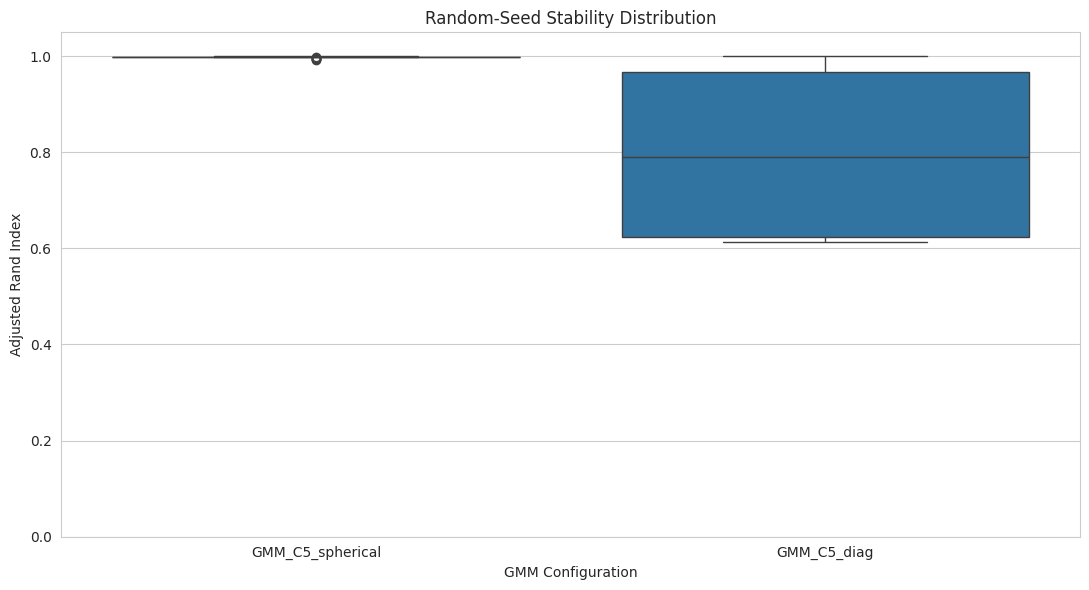

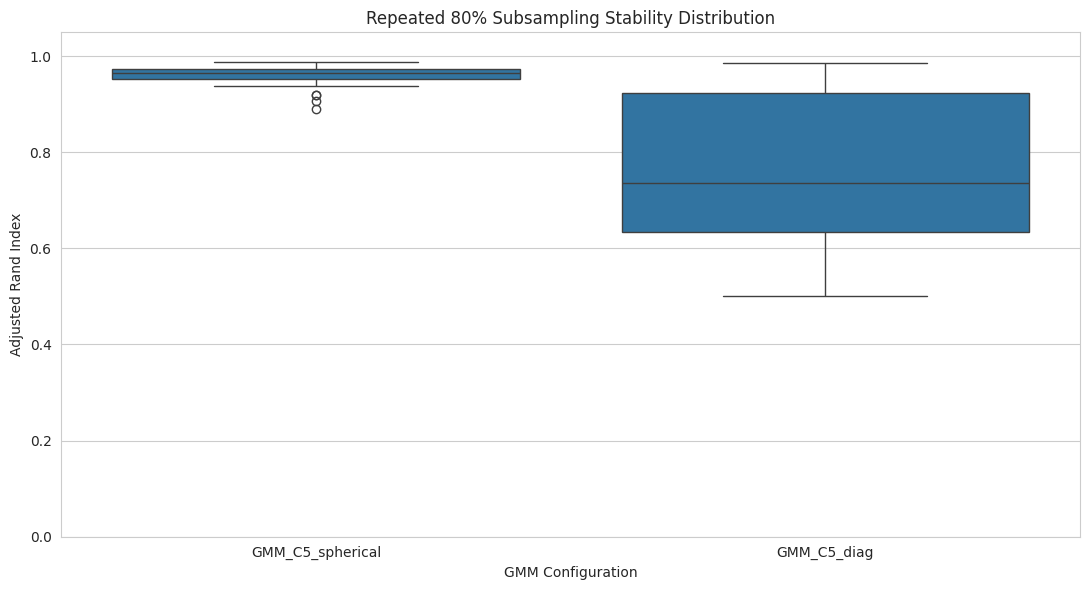

In [ ]:
stability_summary_plot = (
    comparison_evidence[
        [
            "Configuration",
            "Mean_Seed_ARI",
            "Minimum_Seed_ARI",
            "Mean_Subsampling_ARI",
            "Minimum_Subsampling_ARI"
        ]
    ]
    .melt(
        id_vars="Configuration",
        var_name="Stability_Measure",
        value_name="ARI"
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=stability_summary_plot,
    x="Stability_Measure",
    y="ARI",
    hue="Configuration"
)

plt.title(
    "GMM C5 Stability Comparison"
)
plt.xlabel("Stability Measure")
plt.ylabel("Adjusted Rand Index")
plt.ylim(0, 1.05)
plt.xticks(
    rotation=20,
    ha="right"
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_c5_stability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=seed_runs_df,
    x="Configuration",
    y="Adjusted_Rand_Index"
)

plt.title(
    "Random-Seed Stability Distribution"
)
plt.xlabel("GMM Configuration")
plt.ylabel("Adjusted Rand Index")
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_c5_seed_ari_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=subsample_runs_df,
    x="Configuration",
    y="Adjusted_Rand_Index"
)

plt.title(
    "Repeated 80% Subsampling Stability Distribution"
)
plt.xlabel("GMM Configuration")
plt.ylabel("Adjusted Rand Index")
plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_c5_subsampling_ari_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Compare membership decisiveness and PCA visualisations

Probability measures support the decision but do not replace common
validation and stability.

PCA is used only for visualisation. Both models were fitted using all seven
processed features.

,Configuration,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Median_Normalised_Entropy
0,GMM_C5_spherical,0.9221,0.9908,5.2328,0.8503,0.9827,4.4721,0.1201,0.0338
1,GMM_C5_diag,0.9516,0.9982,2.9046,0.9042,0.9965,2.8354,0.0743,0.0085


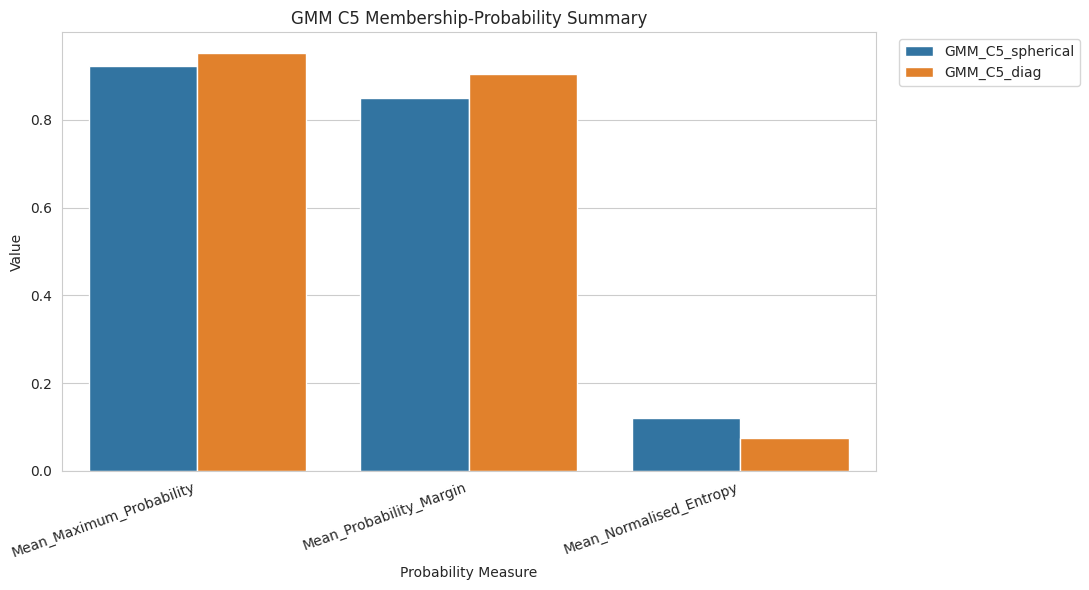

In [ ]:
probability_comparison_columns = [
    "Configuration",
    "Mean_Maximum_Probability",
    "Median_Maximum_Probability",
    "Low_Maximum_Probability_Percentage",
    "Mean_Probability_Margin",
    "Median_Probability_Margin",
    "Low_Probability_Margin_Percentage",
    "Mean_Normalised_Entropy",
    "Median_Normalised_Entropy"
]

probability_comparison = (
    comparison_evidence[
        probability_comparison_columns
    ]
    .copy()
)

display(probability_comparison)

probability_comparison.to_csv(
    TABLES_DIR
    / "gmm_c5_probability_summary_comparison.csv",
    index=False
)

probability_plot_data = (
    probability_comparison[
        [
            "Configuration",
            "Mean_Maximum_Probability",
            "Mean_Probability_Margin",
            "Mean_Normalised_Entropy"
        ]
    ]
    .melt(
        id_vars="Configuration",
        var_name="Probability_Measure",
        value_name="Value"
    )
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=probability_plot_data,
    x="Probability_Measure",
    y="Value",
    hue="Configuration"
)

plt.title(
    "GMM C5 Membership-Probability Summary"
)
plt.xlabel("Probability Measure")
plt.ylabel("Value")
plt.xticks(
    rotation=20,
    ha="right"
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_c5_probability_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

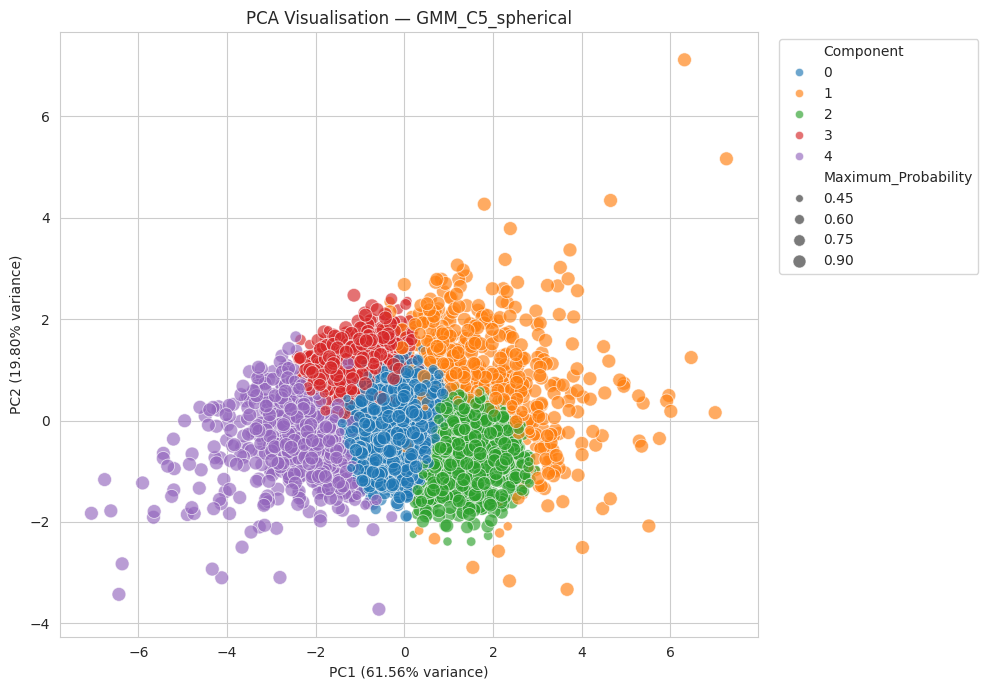

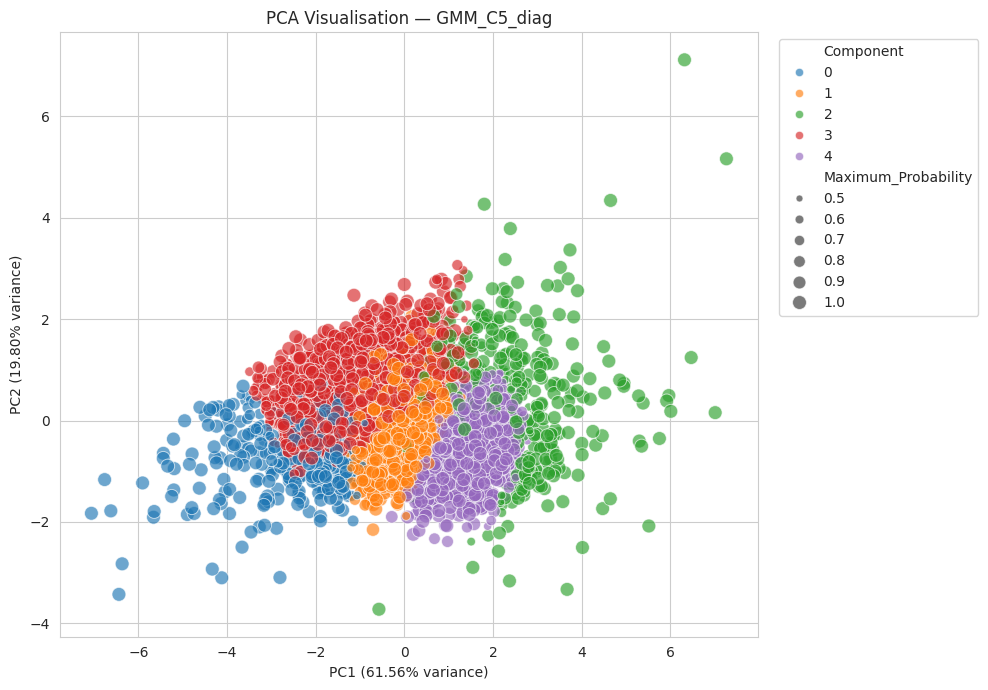

['/content/Final_GMM_C5_Spherical_vs_Diagonal_Results/Models/final_gmm_c5_pca_visualisation.joblib']

In [ ]:
pca = PCA(
    n_components=2,
    random_state=BASELINE_RANDOM_STATE
)

pca_coordinates = pca.fit_transform(
    X
)

pca_base = pd.DataFrame({
    "PC1": pca_coordinates[:, 0],
    "PC2": pca_coordinates[:, 1]
})

for configuration in CANDIDATE_CONFIGURATIONS:

    plot_data = pca_base.copy()

    plot_data[
        "Component"
    ] = baseline_labels[
        configuration
    ]

    plot_data[
        "Maximum_Probability"
    ] = baseline_probability_values[
        configuration
    ][
        "Maximum_Probability"
    ]

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=plot_data,
        x="PC1",
        y="PC2",
        hue="Component",
        size="Maximum_Probability",
        sizes=(20, 100),
        palette="tab10",
        alpha=0.65
    )

    plt.title(
        f"PCA Visualisation — {configuration}"
    )
    plt.xlabel(
        "PC1 "
        f"({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
    )
    plt.ylabel(
        "PC2 "
        f"({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
    )
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"{configuration}_pca_visualisation.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

joblib.dump(
    pca,
    MODELS_DIR
    / "final_gmm_c5_pca_visualisation.joblib"
)

## 15. Apply the transparent final selection conditions

### Operational gates

A candidate passes only when it satisfies:

- convergence;
- smallest full-data component at least 5%;
- mean seed ARI at least 0.80;
- minimum seed ARI at least 0.60;
- mean subsampling ARI at least 0.75;
- minimum subsampling ARI at least 0.60.

These thresholds are project-specific screening rules. They are not universal
GMM quality standards.

### Final choice

- If only one model passes all gates, select that model.
- If both pass, select a model only when the same candidate is stronger on all
  three common validation metrics.
- Otherwise, record that manual profile review is required and do not freeze
  an unsupported final model.

In [ ]:
passing_candidates = (
    comparison_evidence[
        comparison_evidence[
            "Passes_Operational_Gates"
        ]
    ]
    .copy()
)

selection_status = None
selected_configuration = None
selection_reason = None

if len(passing_candidates) == 1:

    selected_configuration = (
        passing_candidates.iloc[0][
            "Configuration"
        ]
    )

    selection_status = (
        "Selected — only candidate passing "
        "all operational gates"
    )

    selection_reason = (
        f"{selected_configuration} was the only "
        "five-component candidate satisfying "
        "convergence, feasibility and stability conditions."
    )

elif len(passing_candidates) == 2:

    spherical_wins_all_common_metrics = (
        (
            spherical_row[
                "Silhouette_Score"
            ]
            >
            diagonal_row[
                "Silhouette_Score"
            ]
        )
        and
        (
            spherical_row[
                "Davies_Bouldin_Index"
            ]
            <
            diagonal_row[
                "Davies_Bouldin_Index"
            ]
        )
        and
        (
            spherical_row[
                "Calinski_Harabasz_Index"
            ]
            >
            diagonal_row[
                "Calinski_Harabasz_Index"
            ]
        )
    )

    diagonal_wins_all_common_metrics = (
        (
            diagonal_row[
                "Silhouette_Score"
            ]
            >
            spherical_row[
                "Silhouette_Score"
            ]
        )
        and
        (
            diagonal_row[
                "Davies_Bouldin_Index"
            ]
            <
            spherical_row[
                "Davies_Bouldin_Index"
            ]
        )
        and
        (
            diagonal_row[
                "Calinski_Harabasz_Index"
            ]
            >
            spherical_row[
                "Calinski_Harabasz_Index"
            ]
        )
    )

    if spherical_wins_all_common_metrics:

        selected_configuration = (
            "GMM_C5_spherical"
        )

        selection_status = (
            "Selected — both candidates passed "
            "and spherical dominated common validation"
        )

        selection_reason = (
            "Both models passed the operational gates. "
            "GMM_C5_spherical achieved the higher "
            "Silhouette Score, lower Davies-Bouldin Index "
            "and higher Calinski-Harabasz Index."
        )

    elif diagonal_wins_all_common_metrics:

        selected_configuration = (
            "GMM_C5_diag"
        )

        selection_status = (
            "Selected — both candidates passed "
            "and diagonal dominated common validation"
        )

        selection_reason = (
            "Both models passed the operational gates. "
            "GMM_C5_diag achieved the higher "
            "Silhouette Score, lower Davies-Bouldin Index "
            "and higher Calinski-Harabasz Index."
        )

    else:

        selection_status = (
            "Not frozen — manual profile review required"
        )

        selection_reason = (
            "Both candidates passed the operational gates, "
            "but neither dominated all three common "
            "validation metrics."
        )

else:

    selection_status = (
        "Not frozen — neither candidate passed "
        "all operational gates"
    )

    selection_reason = (
        "Neither five-component candidate satisfied "
        "the complete convergence, feasibility and "
        "stability conditions."
    )

selection_decision = pd.DataFrame({
    "Selection_Status": [
        selection_status
    ],
    "Selected_Configuration": [
        selected_configuration
    ],
    "Selection_Reason": [
        selection_reason
    ]
})

display(selection_decision)

selection_decision.to_csv(
    SELECTION_DIR
    / "final_gmm_c5_selection_decision.csv",
    index=False
)

,Selection_Status,Selected_Configuration,Selection_Reason
0,Selected — only candidate passing all operatio...,GMM_C5_spherical,GMM_C5_spherical was the only five-component c...


## 16. Freeze the selected five-component GMM

When a supported selection is produced, the notebook saves:

- the selected fitted model;
- fixed customer assignments;
- all five component probabilities;
- original-scale customer features;
- final component sizes;
- final mean, median and quartile profiles;
- a model-freeze record.

Detailed business naming is not applied here. Component names will be assigned
after customer-level membership analysis and profile interpretation.

In [ ]:
if selected_configuration is not None:

    selected_model = baseline_models[
        selected_configuration
    ]

    selected_labels = baseline_labels[
        selected_configuration
    ]

    selected_probabilities = (
        baseline_probabilities[
            selected_configuration
        ]
    )

    selected_probability_values = (
        baseline_probability_values[
            selected_configuration
        ]
    )

    final_customer_data = (
        original_scale_data.copy()
    )

    final_customer_data[
        "GMM_Component"
    ] = selected_labels

    for column_name, values in (
        selected_probability_values.items()
    ):
        final_customer_data[
            column_name
        ] = values

    for component_index in range(
        N_COMPONENTS
    ):
        final_customer_data[
            f"Component_{component_index}_Probability"
        ] = selected_probabilities[
            :,
            component_index
        ]

    final_component_sizes = (
        component_size_table(
            selected_labels
        )
    )

    final_mean_profile = (
        baseline_profiles[
            selected_configuration
        ]["mean"]
    )

    final_median_profile = (
        baseline_profiles[
            selected_configuration
        ]["median"]
    )

    final_quartile_profile = (
        baseline_profiles[
            selected_configuration
        ]["quartile"]
    )

    joblib.dump(
        selected_model,
        MODELS_DIR
        / "final_gmm_c5_model.joblib"
    )

    final_customer_data.to_csv(
        ASSIGNMENTS_DIR
        / "final_gmm_c5_customer_data.csv",
        index=False
    )

    final_component_sizes.to_csv(
        TABLES_DIR
        / "final_gmm_c5_component_sizes.csv",
        index=False
    )

    final_mean_profile.to_csv(
        PROFILES_DIR
        / "final_gmm_c5_mean_profile.csv"
    )

    final_median_profile.to_csv(
        PROFILES_DIR
        / "final_gmm_c5_median_profile.csv"
    )

    final_quartile_profile.to_csv(
        PROFILES_DIR
        / "final_gmm_c5_quartile_profile.csv"
    )

    selected_evidence = (
        comparison_evidence[
            comparison_evidence[
                "Configuration"
            ] == selected_configuration
        ]
        .copy()
    )

    selected_evidence.to_csv(
        SELECTION_DIR
        / "final_gmm_c5_selected_evidence.csv",
        index=False
    )

    freeze_record = {
        "model_name": (
            "Final Five-Component Gaussian Mixture Model"
        ),
        "selected_configuration": (
            selected_configuration
        ),
        "covariance_type": (
            CANDIDATE_CONFIGURATIONS[
                selected_configuration
            ]
        ),
        "customers": int(
            len(X)
        ),
        "features": FEATURE_COLUMNS,
        "n_components": N_COMPONENTS,
        "baseline_random_state": (
            BASELINE_RANDOM_STATE
        ),
        "baseline_n_init": (
            BASELINE_N_INIT
        ),
        "max_iter": MAX_ITER,
        "tolerance": TOLERANCE,
        "reg_covar": REGULARISATION,
        "selection_status": (
            selection_status
        ),
        "selection_reason": (
            selection_reason
        ),
        "business_names_assigned": False,
        "next_step": (
            "Analyse customer-level GMM membership "
            "probabilities and interpret component profiles."
        )
    }

    with open(
        SELECTION_DIR
        / "final_gmm_c5_freeze_record.json",
        "w"
    ) as file:
        json.dump(
            freeze_record,
            file,
            indent=4
        )

    print("=" * 80)
    print("FINAL FIVE-COMPONENT GMM FROZEN")
    print("=" * 80)
    print(
        "Selected configuration:",
        selected_configuration
    )
    print(
        "Model file:",
        MODELS_DIR
        / "final_gmm_c5_model.joblib"
    )

else:

    print("=" * 80)
    print("FINAL GMM NOT FROZEN")
    print("=" * 80)
    print(selection_reason)

FINAL FIVE-COMPONENT GMM FROZEN
Selected configuration: GMM_C5_spherical
Model file: /content/Final_GMM_C5_Spherical_vs_Diagonal_Results/Models/final_gmm_c5_model.joblib


## 17. Run final quality and reproducibility checks

In [ ]:
assert len(X) == 4338
assert X.shape[1] == 7

assert set(
    baseline_results_df[
        "Configuration"
    ]
) == set(
    CANDIDATE_CONFIGURATIONS.keys()
)

assert (
    baseline_results_df[
        "Converged"
    ].all()
)

assert (
    baseline_results_df[
        "All_Components_At_Least_5_Percent"
    ].all()
)

assert (
    seed_summary_df[
        "Successful_Runs"
    ]
    == SEED_STABILITY_RUNS
).all()

assert (
    subsample_summary_df[
        "Successful_Runs"
    ]
    == SUBSAMPLING_STABILITY_RUNS
).all()

assert (
    comparison_evidence[
        "Configuration"
    ].is_unique
)

assert (
    model_agreement_summary[
        "Value"
    ].between(
        0,
        1,
        inclusive="both"
    ).all()
)

required_files = [
    TABLES_DIR
    / "gmm_c5_baseline_comparison.csv",
    TABLES_DIR
    / "gmm_c5_complete_comparison_evidence.csv",
    TABLES_DIR
    / "gmm_c5_criterion_comparison.csv",
    TABLES_DIR
    / "gmm_c5_model_agreement_summary.csv",
    STABILITY_DIR
    / "gmm_c5_random_seed_summary.csv",
    STABILITY_DIR
    / "gmm_c5_subsampling_summary.csv",
    SELECTION_DIR
    / "final_gmm_c5_selection_decision.csv"
]

if selected_configuration is not None:
    required_files.extend([
        MODELS_DIR
        / "final_gmm_c5_model.joblib",
        ASSIGNMENTS_DIR
        / "final_gmm_c5_customer_data.csv",
        TABLES_DIR
        / "final_gmm_c5_component_sizes.csv",
        PROFILES_DIR
        / "final_gmm_c5_mean_profile.csv",
        SELECTION_DIR
        / "final_gmm_c5_freeze_record.json"
    ])

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required files were not created:\n"
        + "\n".join(
            missing_files
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "Customer population fixed at 4,338",
        "Seven-feature matrix preserved",
        "Both five-component candidates evaluated",
        "Both baseline models converged",
        "Both candidates satisfy 5% component feasibility",
        "All 30 seed runs completed for each candidate",
        "All 50 subsampling runs completed for each candidate",
        "Comparison evidence contains unique configurations",
        "Agreement metrics are valid",
        "Required result files created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    TABLES_DIR
    / "final_gmm_c5_quality_checks.csv",
    index=False
)

print(
    "All final GMM C5 quality checks passed."
)

,Quality_Check,Passed
0,"Customer population fixed at 4,338",True
1,Seven-feature matrix preserved,True
2,Both five-component candidates evaluated,True
3,Both baseline models converged,True
4,Both candidates satisfy 5% component feasibility,True
5,All 30 seed runs completed for each candidate,True
6,All 50 subsampling runs completed for each can...,True
7,Comparison evidence contains unique configurat...,True
8,Agreement metrics are valid,True
9,Required result files created,True


All final GMM C5 quality checks passed.


## 18. Create the final supervisor-ready summary

In [ ]:
spherical_summary = (
    comparison_evidence[
        comparison_evidence[
            "Configuration"
        ] == "GMM_C5_spherical"
    ]
    .iloc[0]
)

diagonal_summary = (
    comparison_evidence[
        comparison_evidence[
            "Configuration"
        ] == "GMM_C5_diag"
    ]
    .iloc[0]
)

supervisor_summary = f'''
FINAL FIVE-COMPONENT GMM SELECTION SUMMARY

Dataset
-------
Customers: {len(X):,}
Features: {len(FEATURE_COLUMNS)}
Components: {N_COMPONENTS}

Candidates
----------
1. GMM_C5_spherical
2. GMM_C5_diag

GMM_C5_spherical
----------------
Silhouette: {spherical_summary["Silhouette_Score"]:.4f}
Davies-Bouldin: {spherical_summary["Davies_Bouldin_Index"]:.4f}
Calinski-Harabasz: {spherical_summary["Calinski_Harabasz_Index"]:.2f}
AIC: {spherical_summary["AIC"]:.2f}
BIC: {spherical_summary["BIC"]:.2f}
Smallest component: {spherical_summary["Smallest_Component_Percentage"]:.2f}%
Mean seed ARI: {spherical_summary["Mean_Seed_ARI"]:.4f}
Minimum seed ARI: {spherical_summary["Minimum_Seed_ARI"]:.4f}
Mean subsampling ARI: {spherical_summary["Mean_Subsampling_ARI"]:.4f}
Minimum subsampling ARI: {spherical_summary["Minimum_Subsampling_ARI"]:.4f}
Mean maximum probability: {spherical_summary["Mean_Maximum_Probability"]:.4f}

GMM_C5_diag
-----------
Silhouette: {diagonal_summary["Silhouette_Score"]:.4f}
Davies-Bouldin: {diagonal_summary["Davies_Bouldin_Index"]:.4f}
Calinski-Harabasz: {diagonal_summary["Calinski_Harabasz_Index"]:.2f}
AIC: {diagonal_summary["AIC"]:.2f}
BIC: {diagonal_summary["BIC"]:.2f}
Smallest component: {diagonal_summary["Smallest_Component_Percentage"]:.2f}%
Mean seed ARI: {diagonal_summary["Mean_Seed_ARI"]:.4f}
Minimum seed ARI: {diagonal_summary["Minimum_Seed_ARI"]:.4f}
Mean subsampling ARI: {diagonal_summary["Mean_Subsampling_ARI"]:.4f}
Minimum subsampling ARI: {diagonal_summary["Minimum_Subsampling_ARI"]:.4f}
Mean maximum probability: {diagonal_summary["Mean_Maximum_Probability"]:.4f}

Cross-model agreement
---------------------
ARI: {cross_model_ari:.4f}
NMI: {cross_model_nmi:.4f}

Final decision
--------------
Status: {selection_status}
Selected configuration: {selected_configuration}
Reason: {selection_reason}

Interpretation
--------------
The final five-component GMM was selected using convergence,
component feasibility, random-seed stability, repeated 80%
subsampling stability and common hard-assignment validation.

AIC, BIC and probability decisiveness were retained as supporting
GMM-specific evidence. They were not used alone to select the
operational segmentation.
'''.strip()

with open(
    RESULTS_DIR
    / "supervisor_final_gmm_c5_summary.txt",
    "w"
) as file:
    file.write(
        supervisor_summary
    )

print(supervisor_summary)

FINAL FIVE-COMPONENT GMM SELECTION SUMMARY

Dataset
-------
Customers: 4,338
Features: 7
Components: 5

Candidates
----------
1. GMM_C5_spherical
2. GMM_C5_diag

GMM_C5_spherical
----------------
Silhouette: 0.2299
Davies-Bouldin: 1.3749
Calinski-Harabasz: 1587.50
AIC: 50691.22
BIC: 50971.72
Smallest component: 11.39%
Mean seed ARI: 0.9985
Minimum seed ARI: 0.9918
Mean subsampling ARI: 0.9610
Minimum subsampling ARI: 0.8898
Mean maximum probability: 0.9221

GMM_C5_diag
-----------
Silhouette: 0.1329
Davies-Bouldin: 1.7975
Calinski-Harabasz: 1149.40
AIC: 36948.95
BIC: 37420.71
Smallest component: 8.09%
Mean seed ARI: 0.7894
Minimum seed ARI: 0.6129
Mean subsampling ARI: 0.7621
Minimum subsampling ARI: 0.5005
Mean maximum probability: 0.9516

Cross-model agreement
---------------------
ARI: 0.4449
NMI: 0.5077

Final decision
--------------
Status: Selected — only candidate passing all operational gates
Selected configuration: GMM_C5_spherical
Reason: GMM_C5_spherical was the only five-co

## 19. Save the final methodology manifest

In [ ]:
methodology_manifest = {
    "notebook_purpose": (
        "Select and freeze the final five-component GMM "
        "from spherical and diagonal covariance candidates."
    ),
    "dataset": {
        "customers": int(
            len(X)
        ),
        "features": FEATURE_COLUMNS
    },
    "candidate_configurations": (
        CANDIDATE_CONFIGURATIONS
    ),
    "baseline_training": {
        "random_state": BASELINE_RANDOM_STATE,
        "n_init": BASELINE_N_INIT,
        "max_iter": MAX_ITER,
        "tol": TOLERANCE,
        "reg_covar": REGULARISATION,
        "init_params": INITIALISATION
    },
    "stability_testing": {
        "seed_runs": SEED_STABILITY_RUNS,
        "subsampling_runs": (
            SUBSAMPLING_STABILITY_RUNS
        ),
        "subsampling_fraction": (
            SUBSAMPLE_FRACTION
        ),
        "shared_subsamples_between_candidates": True,
        "stability_n_init": STABILITY_N_INIT
    },
    "operational_gate_thresholds": {
        "minimum_component_percentage": (
            MINIMUM_COMPONENT_PERCENTAGE
        ),
        "minimum_mean_seed_ari": (
            MINIMUM_MEAN_SEED_ARI
        ),
        "minimum_worst_seed_ari": (
            MINIMUM_WORST_SEED_ARI
        ),
        "minimum_mean_subsampling_ari": (
            MINIMUM_MEAN_SUBSAMPLE_ARI
        ),
        "minimum_worst_subsampling_ari": (
            MINIMUM_WORST_SUBSAMPLE_ARI
        ),
        "note": (
            "Project-specific transparent screening "
            "conditions rather than universal standards."
        )
    },
    "selection": {
        "status": selection_status,
        "selected_configuration": (
            selected_configuration
        ),
        "reason": selection_reason
    },
    "next_step": (
        "Analyse customer-level GMM membership "
        "probabilities, alternative components and entropy."
    )
}

with open(
    RESULTS_DIR
    / "final_gmm_c5_methodology_manifest.json",
    "w"
) as file:
    json.dump(
        methodology_manifest,
        file,
        indent=4
    )

print(
    "Methodology manifest saved."
)

Methodology manifest saved.


## 20. Create the final results ZIP archive

In [ ]:
zip_path = shutil.make_archive(
    base_name=(
        "/content/"
        "Final_GMM_C5_Spherical_vs_Diagonal_Results"
    ),
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("FINAL GMM C5 NOTEBOOK COMPLETED")
print("=" * 80)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nKey files:")
print("1. gmm_c5_baseline_comparison.csv")
print("2. gmm_c5_complete_comparison_evidence.csv")
print("3. gmm_c5_random_seed_summary.csv")
print("4. gmm_c5_subsampling_summary.csv")
print("5. gmm_c5_criterion_comparison.csv")
print("6. gmm_c5_model_agreement_summary.csv")
print("7. final_gmm_c5_selection_decision.csv")
print("8. final_gmm_c5_model.joblib, when selected")
print("9. final_gmm_c5_customer_data.csv, when selected")
print("10. supervisor_final_gmm_c5_summary.txt")

FINAL GMM C5 NOTEBOOK COMPLETED

Results folder:
/content/Final_GMM_C5_Spherical_vs_Diagonal_Results

ZIP archive:
/content/Final_GMM_C5_Spherical_vs_Diagonal_Results.zip

Key files:
1. gmm_c5_baseline_comparison.csv
2. gmm_c5_complete_comparison_evidence.csv
3. gmm_c5_random_seed_summary.csv
4. gmm_c5_subsampling_summary.csv
5. gmm_c5_criterion_comparison.csv
6. gmm_c5_model_agreement_summary.csv
7. final_gmm_c5_selection_decision.csv
8. final_gmm_c5_model.joblib, when selected
9. final_gmm_c5_customer_data.csv, when selected
10. supervisor_final_gmm_c5_summary.txt


## Final interpretation rules

- A selected component label is not yet a business segment name.
- GMM component numbers are arbitrary.
- Posterior probabilities describe membership under the fitted mixture model;
  they are not verified real-world classification probabilities.
- A model can have better AIC/BIC but weaker hard-assignment separation.
- Stability and practical component sizes are required for the operational
  segmentation.
- The selected GMM must remain fixed before detailed customer-level membership
  analysis and the final K-Means-versus-GMM comparison.